In [1]:
import scanpy as sc
import pandas as pd
import numpy as nu
from scipy.sparse import csr_matrix

from matplotlib import pyplot as plt
from matplotlib import rcParams
%matplotlib inline
import sys
#sys.path.append("../src/bachclue")
import bachclue as bc

In [2]:
bc

<module 'bachclue' from '/opt/conda/envs/spatialdata/lib/python3.10/site-packages/bachclue/__init__.py'>

In [3]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=200, facecolor='white')

## 3kPBMC dataset

"K-means clustering on the first 50 PCs identified 10 distinct cell clusters, which were visualized in two-dimensional projection of t-distributed stochastic neighbour embedding (tSNE)..."
— Zheng et al., Nature Communications, 2017, page 5

But they were using PBMC 68k

https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering-2017.html

Scanpy tutorial on 3k dataset finds and annotates 8 clusters


In [3]:
adata = sc.read_h5ad("../../tests/datasets/3kPBMC_data/processed_data.h5ad")

Performing 24 parallel clusterings
Using 24/32 CPU cores
Starting parallel computation with Joblib using 24 cores...

Best resolution: 0.10


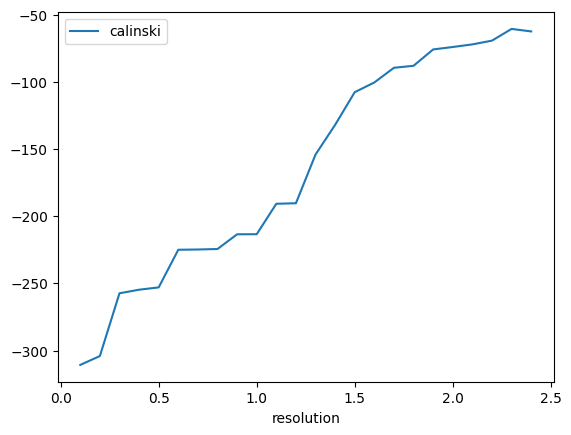

In [4]:
a = bc.clustering_score(adata, score_value = 'calinski', min_res=0.1,max_res=2.5,step=0.1, plot=True, dim_reduction = 'pca')

In [15]:
a[1]

0.1

Performing 24 parallel clusterings
Using 24/32 CPU cores
Starting parallel computation with Joblib using 24 cores...

Best resolution: 0.90


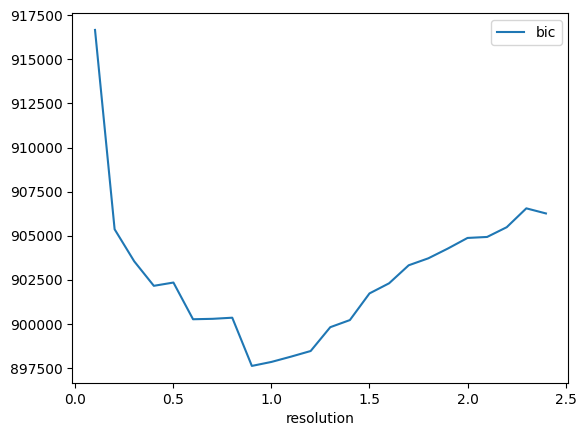

In [5]:
b = bc.clustering_score(adata, score_value = 'bic', min_res=0.1,max_res=2.5,step=0.1, plot=True, dim_reduction = 'pca')

In [16]:
b[1]

0.9

Clustering by using the resolution 0.10, step 1 of 24
Clustering by using the resolution 0.20, step 2 of 24
Clustering by using the resolution 0.30, step 3 of 24
Clustering by using the resolution 0.40, step 4 of 24
Clustering by using the resolution 0.50, step 5 of 24
Clustering by using the resolution 0.60, step 6 of 24
Clustering by using the resolution 0.70, step 7 of 24
Clustering by using the resolution 0.80, step 8 of 24
Clustering by using the resolution 0.90, step 9 of 24
Clustering by using the resolution 1.00, step 10 of 24
Clustering by using the resolution 1.10, step 11 of 24
Clustering by using the resolution 1.20, step 12 of 24
Clustering by using the resolution 1.30, step 13 of 24
Clustering by using the resolution 1.40, step 14 of 24
Clustering by using the resolution 1.50, step 15 of 24
Clustering by using the resolution 1.60, step 16 of 24
Clustering by using the resolution 1.70, step 17 of 24
Clustering by using the resolution 1.80, step 18 of 24
Clustering by using

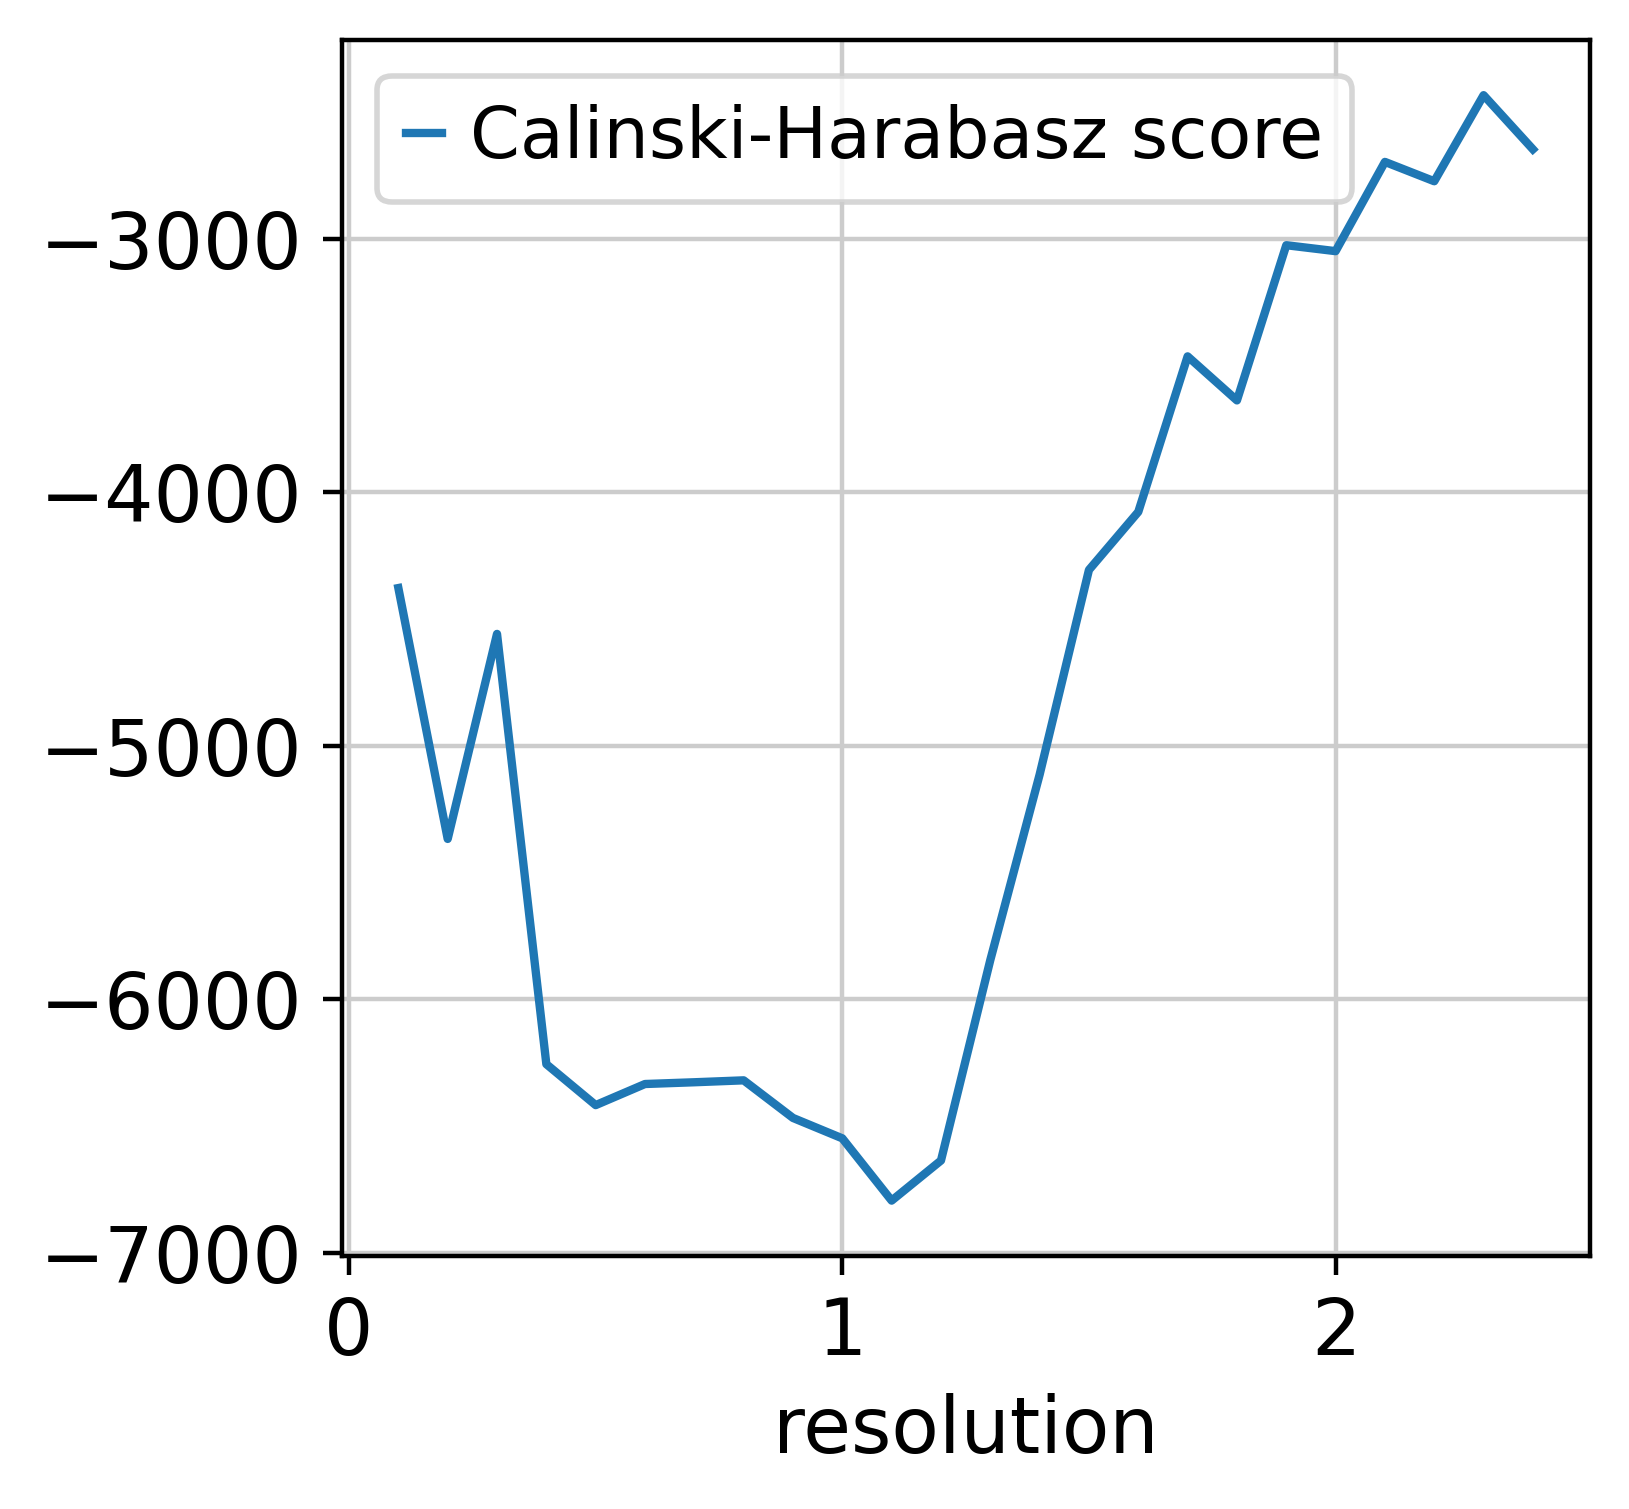

In [11]:
c = bc.clustering_score(adata, score_value = 'calinski', min_res=0.1,max_res=2.5,step=0.1, plot=True, dim_reduction = 'umap')

In [17]:
c[1]

1.1

Performing 24 parallel clusterings
Using 24/32 CPU cores
Starting parallel computation with Joblib using 24 cores...

Best resolution: 0.90


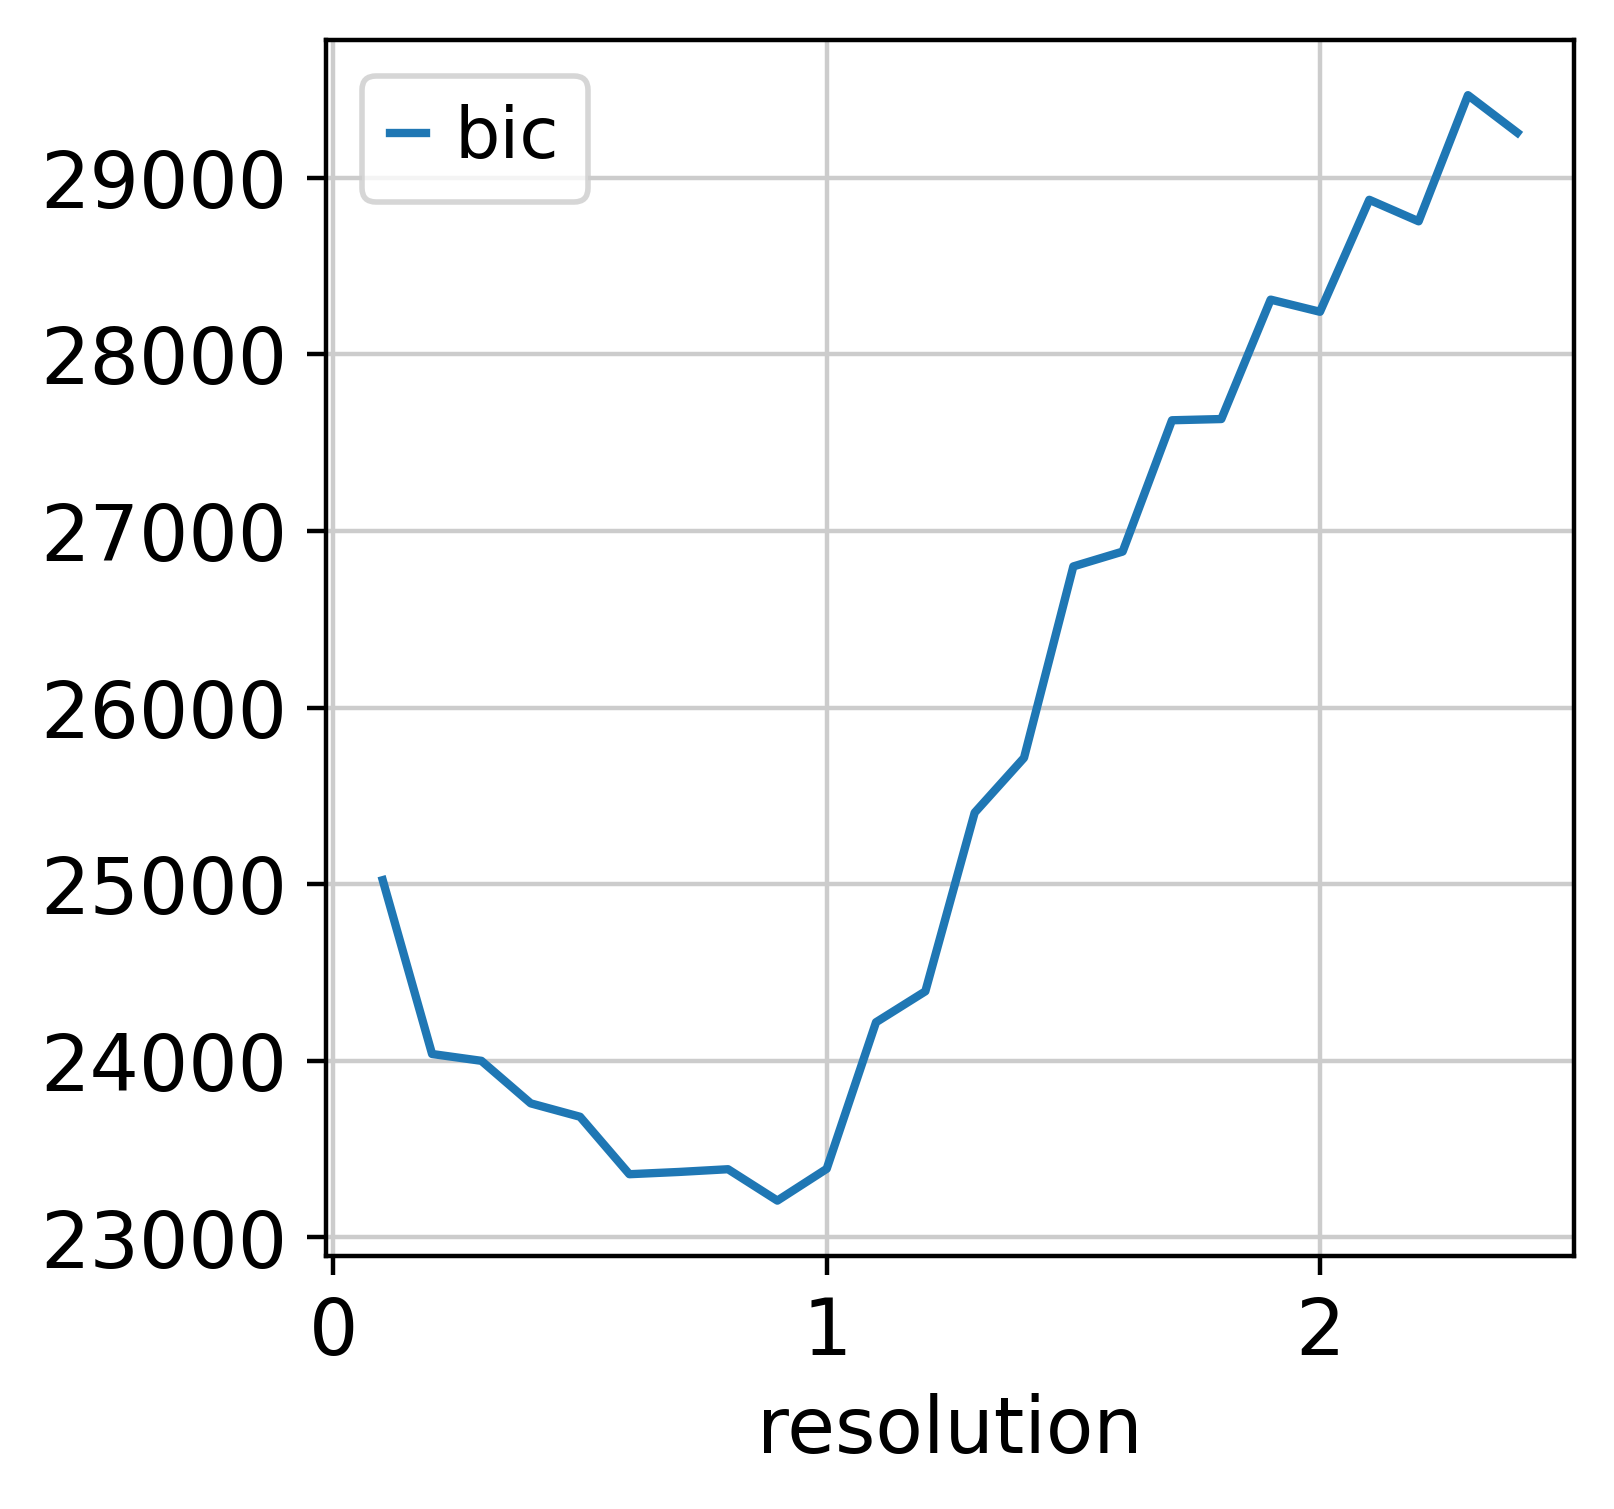

In [7]:
d = bc.clustering_score(adata, score_value = 'bic', min_res=0.1,max_res=2.5,step=0.1, plot=True, dim_reduction = 'umap')

In [18]:
d[1]

0.9

/shared/home/ssarnata/.conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


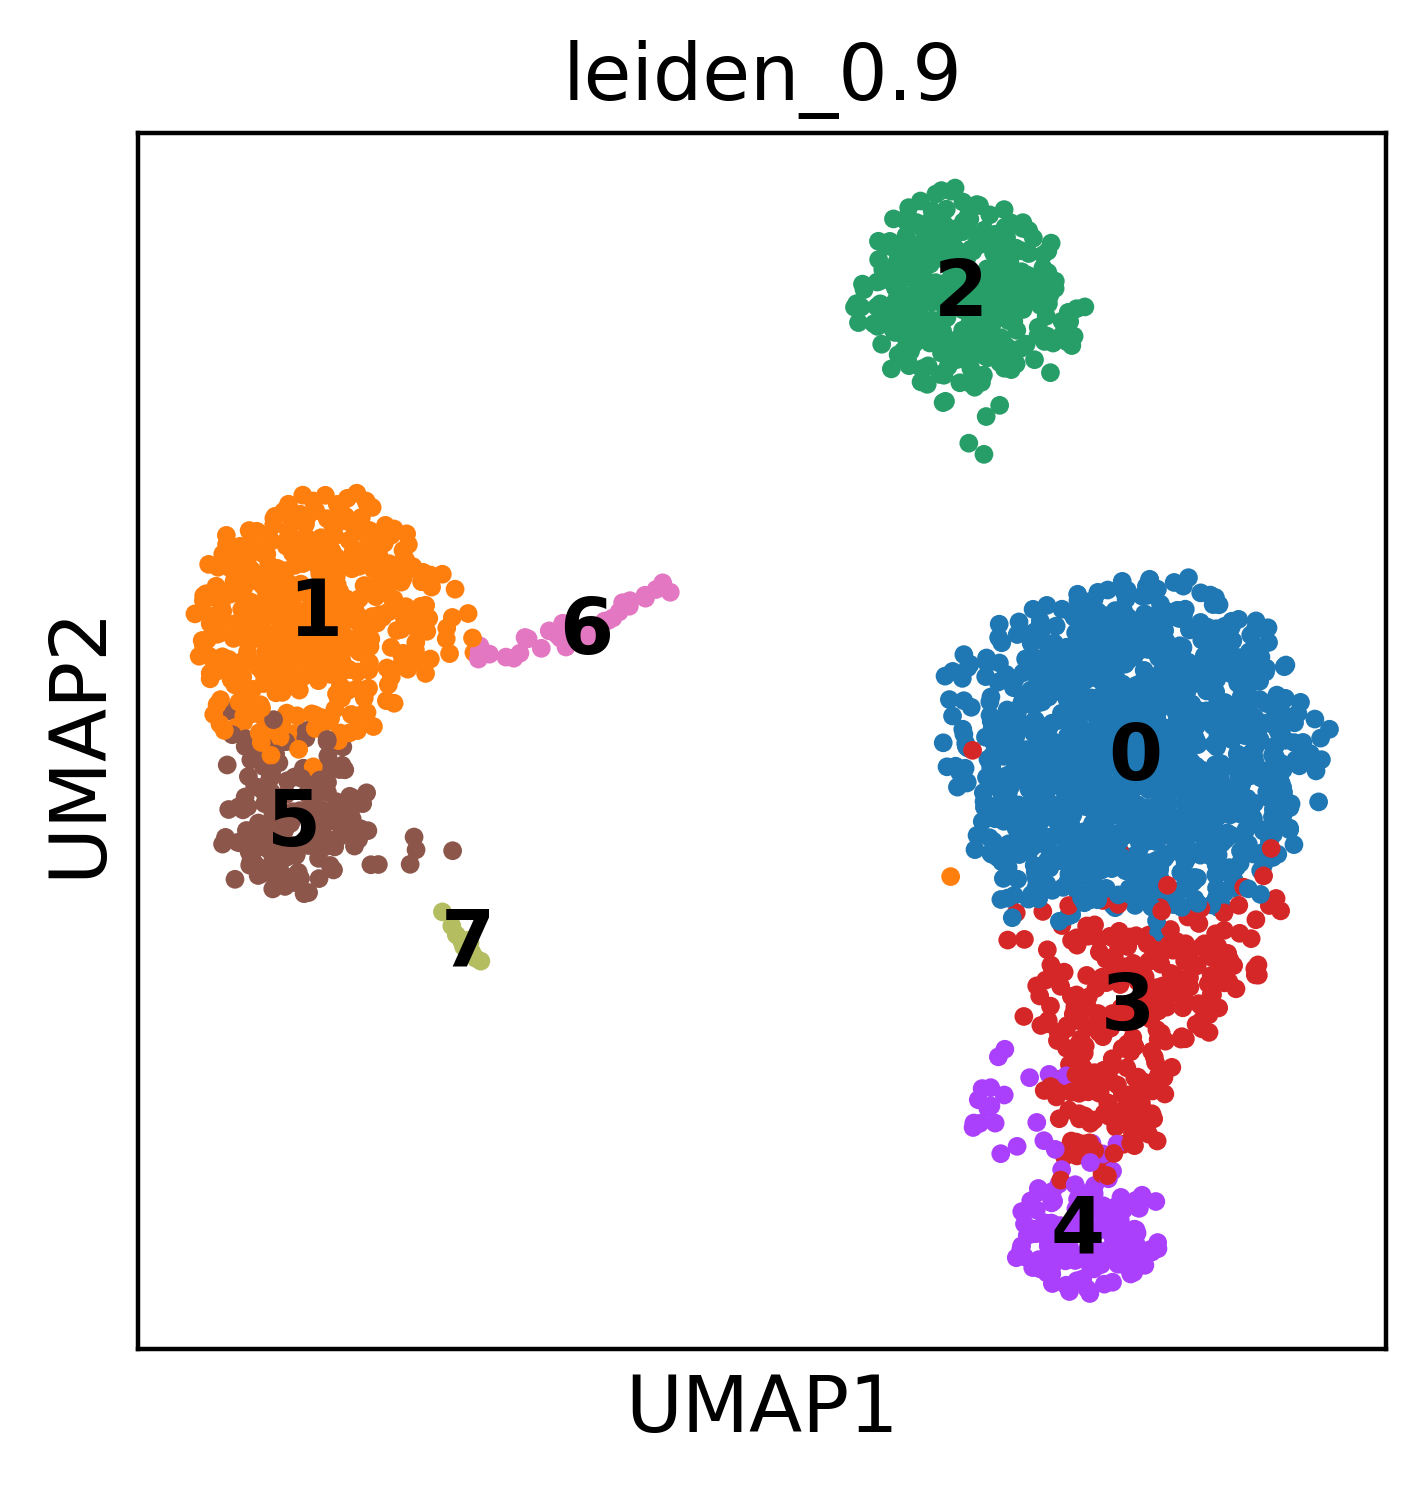

/shared/home/ssarnata/.conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


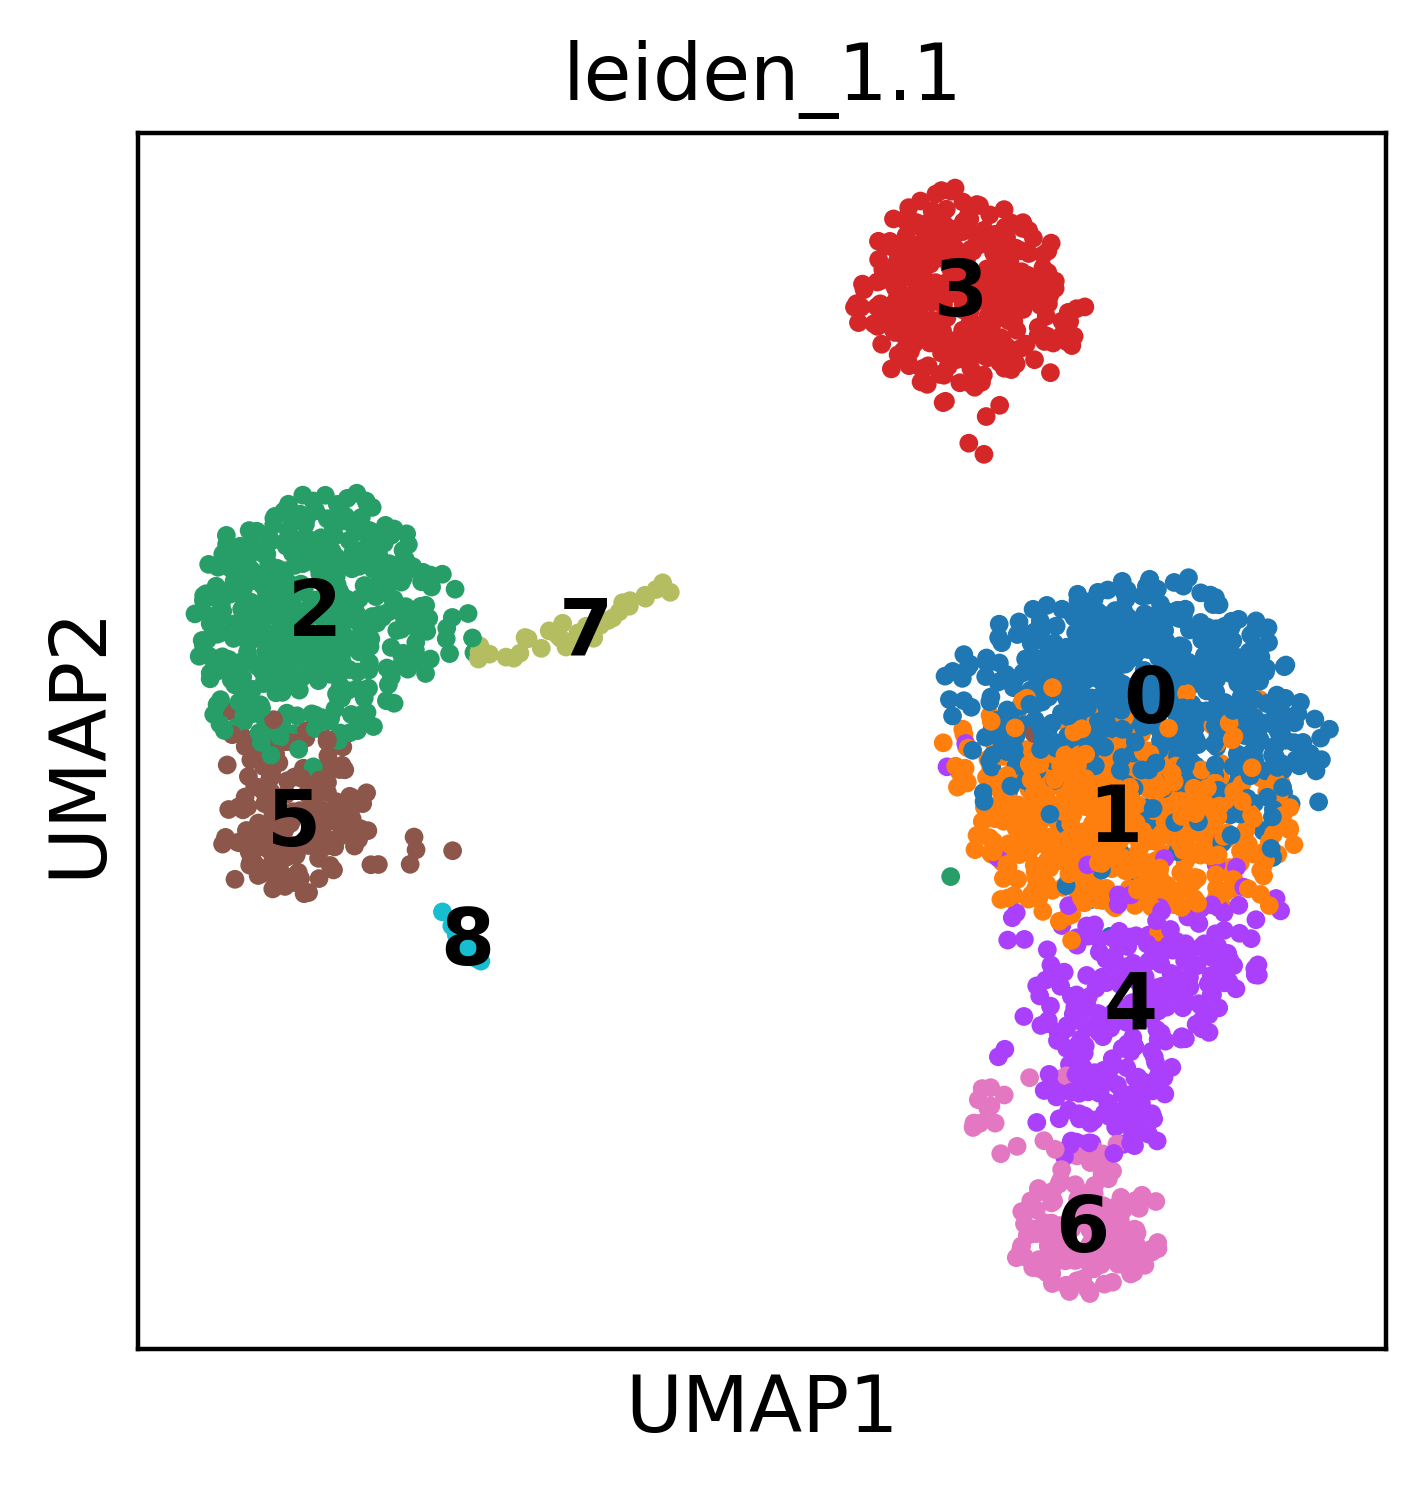

In [19]:
for res in [0.9,1.1]:
    sc.tl.leiden(adata, key_added="leiden_%s" %res, resolution=res)
    sc.pl.umap(adata, color="leiden_%s" %res,legend_loc="on data")

- Bic best res: 0.9 -> 8 clusters: OK
- Calinski best res: 1.1 -> 9 clusters: reference is 8